# Layer 06 — Build Property Knowledge Base

This notebook constructs the **Property Knowledge Base (KB)** and loads it into **Neo4j AuraDB**.

## Steps

1. Load feature table from Layer 02 (263k rows → deduplicated to unique properties)
2. Decode OHE columns → human-readable town, flat_type, flat_model
3. Identify famous primary schools from MOE data (`autonomous_ind`, `gifted_ind`, `sap_ind`)
4. Enrich each property with Haversine distance to nearest famous school
5. Normalise all features to 0–10 scores (p5–p95 percentile clipping)
6. Save parquet KB + normalization params
7. **Push to Neo4j** — nodes (Property, FamousSchool, Town) + relationships

## Artefacts

| File | Contents |
|------|----------|
| `artifacts/property_knowledge_base_YYYYMMDD.parquet` | 9,710 unique properties with all scores |
| `artifacts/search_norm_params_YYYYMMDD.json` | p5/p95 normalization bounds |
| `artifacts/famous_school_distances_YYYYMMDD.parquet` | Pairwise distances within 2 km (for Neo4j relationships) |

## Neo4j graph model

```
(:Property)  ─[:LOCATED_IN]──────────────────►  (:Town)
(:Property)  ─[:NEAREST_FAMOUS_SCHOOL {dist}]►  (:FamousSchool)
(:Property)  ─[:NEAR_FAMOUS_SCHOOL {dist}]───►  (:FamousSchool)  ← within 2 km
```

## Cell 1 — Imports & repo root

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Standard PropertyLens path resolution
cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / 'hf_data').exists() else cwd.parent
LAYER_DIR = REPO_ROOT / '06_search_layer'

if str(LAYER_DIR) not in sys.path:
    sys.path.insert(0, str(LAYER_DIR))

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'LAYER_DIR : {LAYER_DIR}')

REPO_ROOT : /Users/lorenzolou/Library/Mobile Documents/com~apple~CloudDocs/NUS/PropertyLens
LAYER_DIR : /Users/lorenzolou/Library/Mobile Documents/com~apple~CloudDocs/NUS/PropertyLens/06_search_layer


## Cell 2 — Resolve source file paths

In [2]:
# Feature table
feat_dir = REPO_ROOT / 'hf_data' / '02_feature_layer' / 'training' / 'outputs'
if not feat_dir.exists():
    feat_dir = REPO_ROOT / '02_feature_layer' / 'training' / 'outputs'

feature_csvs = sorted(p for p in feat_dir.glob('hdb_feature_table_*.csv') if '_backup_' not in p.name)
feature_csv = feature_csvs[-1]
print(f'Feature table : {feature_csv.name}')

school_dir = REPO_ROOT / '01_data_layer' / 'raw' / 'schools'
school_info_csv = sorted(school_dir.glob('moe_general_information_of_schools_*.csv'))[-1]
print(f'School info   : {school_info_csv.name}')

geo_dir = REPO_ROOT / '01_data_layer' / 'raw' / 'google_geo'
school_geocode_csv = sorted(geo_dir.glob('moe_school_geocode_*.csv'))[-1]
print(f'School geocode: {school_geocode_csv.name}')

hdb_geocode_csv = sorted(geo_dir.glob('hdb_geo_accessibility_noise_features_*.csv'))[-1]
print(f'HDB geocode   : {hdb_geocode_csv.name}')

Feature table : hdb_feature_table_20260412.csv
School info   : moe_general_information_of_schools_20260412.csv
School geocode: moe_school_geocode_20260412.csv
HDB geocode   : hdb_geo_accessibility_noise_features_20260412.csv


In [3]:
# Quick schema peek
df_peek = pd.read_csv(feature_csv, nrows=3)
print(f'Feature table columns ({len(df_peek.columns)}):', list(df_peek.columns)[:25], '...')
n_rows = sum(1 for _ in open(feature_csv)) - 1
print(f'Total rows: {n_rows:,}')

Feature table columns (86): ['resale_price', 'transaction_year', 'level_mid', 'lease_remaining_years', 'floor_area_sqm', 'room_count', 'dist_to_mrt_m', 'orientation_score', 'dist_to_highway_m', 'dist_to_foodcourt_m', 'dist_to_nearest_mall_m', 'mall_count_3km', 'mall_weighted_access_3km', 'dist_to_nearest_school_m', 'school_count_1km', 'primary_school_quality_1km_weighted', 'primary_school_count_1km', 'years_since_transaction', 'recency_normalized', 'years_since_transaction_sq', 'recency_x_school_quality', 'recency_x_mall_access', 'address_key', 'town_ANG MO KIO', 'town_BEDOK'] ...
Total rows: 263,004


## Cell 3 — Preview famous primary schools

In [4]:
school_info = pd.read_csv(school_info_csv)
is_primary = school_info['mainlevel_code'].str.upper().str.contains('PRIMARY', na=False)
is_famous  = (
    school_info['autonomous_ind'].str.upper().eq('YES')
    | school_info['gifted_ind'].str.upper().eq('YES')
    | school_info['sap_ind'].str.upper().eq('YES')
)
famous_info = school_info[is_primary & is_famous]
print(f'Famous primary schools: {len(famous_info)}')
print(famous_info[['school_name', 'autonomous_ind', 'gifted_ind', 'sap_ind']].to_string(index=False))

Famous primary schools: 17
                        school_name autonomous_ind gifted_ind sap_ind
                     AI TONG SCHOOL             No         No     Yes
     ANGLO-CHINESE SCHOOL (PRIMARY)             No        Yes      No
          HENRY PARK PRIMARY SCHOOL             No        Yes      No
     HOLY INNOCENTS' PRIMARY SCHOOL             No         No     Yes
                    HONG WEN SCHOOL             No         No     Yes
                    KONG HWA SCHOOL             No         No     Yes
                  MAHA BODHI SCHOOL             No         No     Yes
             NAN HUA PRIMARY SCHOOL             No        Yes     Yes
             NANYANG PRIMARY SCHOOL             No        Yes     Yes
             PEI CHUN PUBLIC SCHOOL             No         No     Yes
PEI HWA PRESBYTERIAN PRIMARY SCHOOL             No         No     Yes
                   POI CHING SCHOOL             No         No     Yes
      RAFFLES GIRLS' PRIMARY SCHOOL             No        Yes  

## Cell 4 — Build the Knowledge Base

Runs the full pipeline. Also saves `famous_school_distances_*.parquet` for Neo4j relationship creation.

In [5]:
from yc_property_search import PropertyKnowledgeBase

kb = PropertyKnowledgeBase.build(
    feature_csv=feature_csv,
    school_info_csv=school_info_csv,
    school_geocode_csv=school_geocode_csv,
    hdb_geocode_csv=hdb_geocode_csv,
    output_dir=LAYER_DIR / 'artifacts',
)

print(f'\n{kb}')

[1/6] Loading feature table: hdb_feature_table_20260412.csv
      263,004 rows × 86 cols loaded
      9,710 unique properties after deduplication
[2/6] Decoding OHE columns → town, flat_type, flat_model...
[3/6] Identifying famous primary schools from MOE data...
      17 famous primary schools identified:
        • AI TONG SCHOOL
        • ANGLO-CHINESE SCHOOL (PRIMARY)
        • HENRY PARK PRIMARY SCHOOL
        • HOLY INNOCENTS' PRIMARY SCHOOL
        • HONG WEN SCHOOL
        • KONG HWA SCHOOL
        • MAHA BODHI SCHOOL
        • NAN HUA PRIMARY SCHOOL
        • NANYANG PRIMARY SCHOOL
        • PEI CHUN PUBLIC SCHOOL
        • PEI HWA PRESBYTERIAN PRIMARY SCHOOL
        • POI CHING SCHOOL
        • RAFFLES GIRLS' PRIMARY SCHOOL
        • RED SWASTIKA SCHOOL
        • ROSYTH SCHOOL
        • ST. HILDA'S PRIMARY SCHOOL
        • TAO NAN SCHOOL
[4/6] Computing distances to famous primary schools (vectorised Haversine)...
      Geocode match rate: 100.0% (9,710/9,710)
      16.8% of p

/Users/lorenzolou/Library/Mobile Documents/com~apple~CloudDocs/NUS/PropertyLens/06_search_layer/yc_property_search.py:487: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[score_name] = _normalize_series(vals, p5, p95, dim["direction"])


## Cell 5 — Validate KB

In [6]:
print(f'KB shape: {kb.kb.shape}')
display(kb.kb[['address_key', 'town', 'flat_type', 'floor_area_sqm', 'resale_price',
               'dist_to_nearest_famous_school_km', 'nearest_famous_school_name',
               'score_famous_school', 'score_mrt', 'score_value']].head(5))

KB shape: (9710, 38)


,address_key,town,flat_type,floor_area_sqm,resale_price,dist_to_nearest_famous_school_km,nearest_famous_school_name,score_famous_school,score_mrt,score_value
0,611 YISHUN ST 61,YISHUN,EXECUTIVE,146.0,860088.0,6.6383,AI TONG SCHOOL,3.4283,4.1587,2.2386
1,470B UPP SERANGOON CRES,HOUGANG,3 ROOM,67.0,558000.0,1.5369,HOLY INNOCENTS' PRIMARY SCHOOL,8.8079,9.3633,7.0720
2,688 HOUGANG ST 61,HOUGANG,3 ROOM,74.0,440000.0,1.2532,ROSYTH SCHOOL,9.1070,8.4928,8.9600
3,685 HOUGANG ST 61,HOUGANG,3 ROOM,64.0,400000.0,1.2771,ROSYTH SCHOOL,9.0818,8.4312,9.6000
4,246 HOUGANG ST 22,HOUGANG,3 ROOM,67.0,410000.0,0.9558,HOLY INNOCENTS' PRIMARY SCHOOL,9.4206,8.9137,9.4400


In [7]:
# Score distribution — medians should all be near 5.0
display(kb.score_summary())

,count,mean,std,min,25%,50%,75%,max
score_dimension,,,,,,,,
score_mrt,9710.0,7.011,2.992,0.0,5.908,8.080,9.315,10.0
score_food,9710.0,6.055,2.856,0.0,4.255,6.572,8.368,10.0
score_shopping,9710.0,5.998,2.813,0.0,4.164,6.427,8.244,10.0
score_school_proximity,9710.0,6.369,2.795,0.0,4.686,7.001,8.587,10.0
score_school_quality,9710.0,5.000,0.000,5.0,5.000,5.000,5.000,5.0
score_famous_school,9710.0,6.416,3.046,0.0,4.246,7.378,8.974,10.0
score_size,9710.0,4.520,2.939,0.0,2.439,4.634,6.829,10.0
score_floor,9710.0,3.711,3.018,0.0,2.000,4.000,6.000,10.0
score_lease,9710.0,4.426,2.864,0.0,2.381,4.048,6.190,10.0


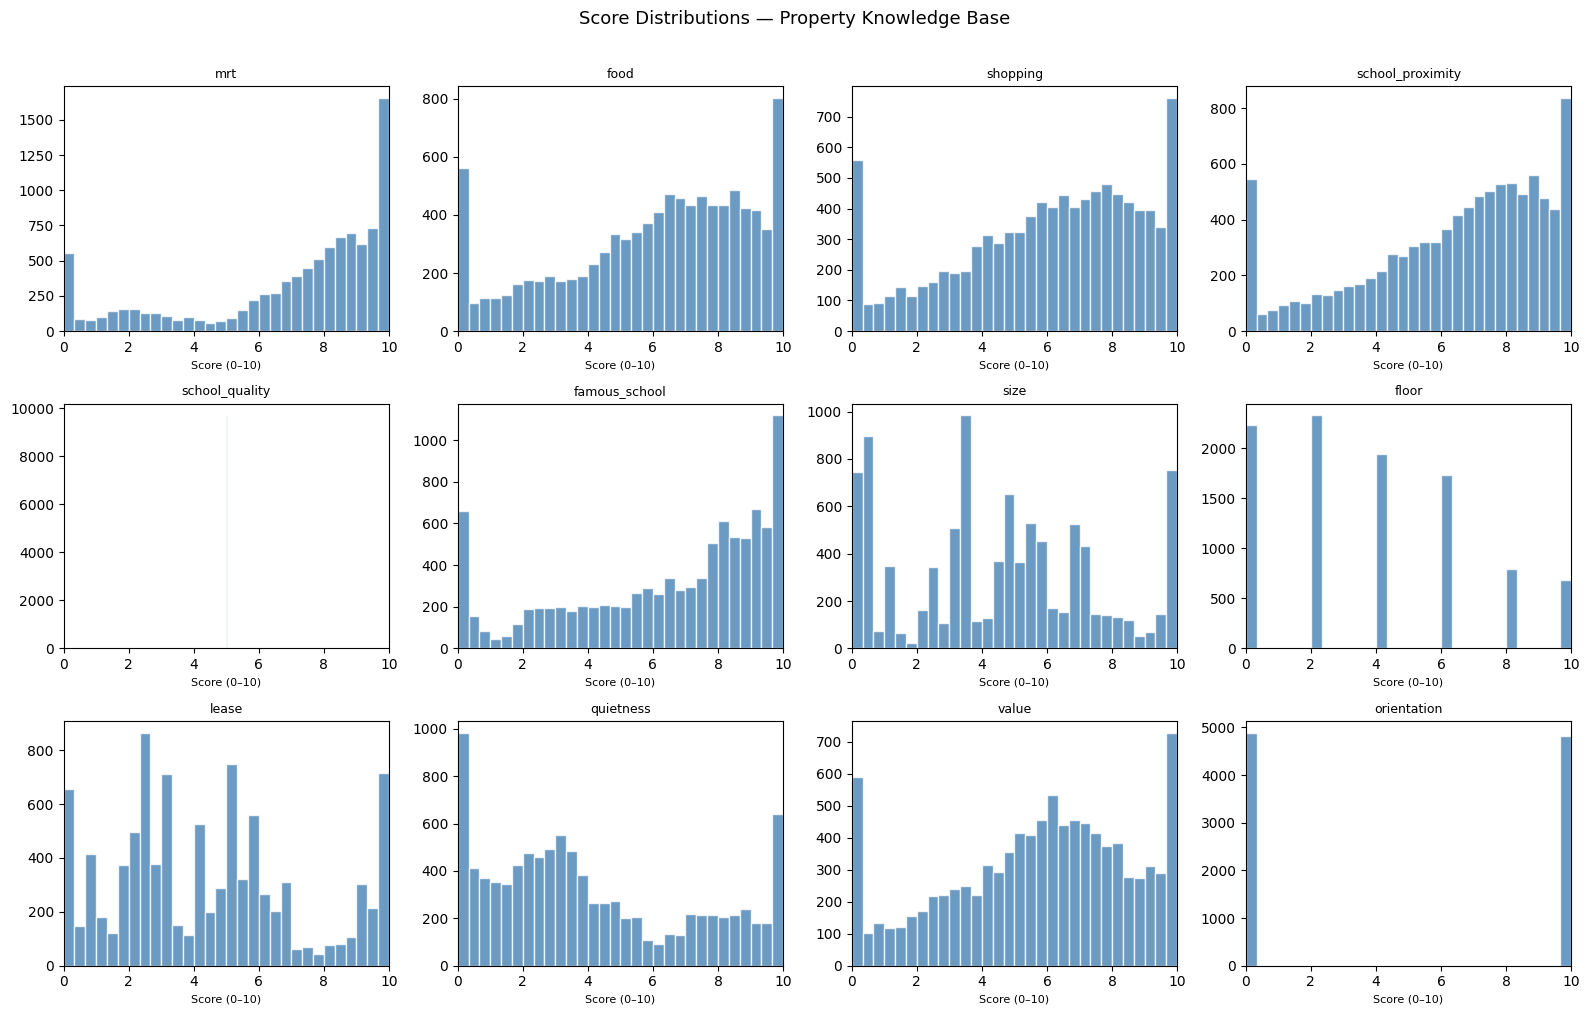

In [8]:
score_cols = [c for c in kb.kb.columns if c.startswith('score_')]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(score_cols):
    axes[i].hist(kb.kb[col], bins=30, edgecolor='white', color='steelblue', alpha=0.8)
    axes[i].set_title(col.replace('score_', ''), fontsize=9)
    axes[i].set_xlabel('Score (0–10)', fontsize=8)
    axes[i].set_xlim(0, 10)
for j in range(len(score_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score Distributions — Property Knowledge Base', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
within_1km = (kb.kb['famous_school_count_1km'] > 0).sum()
total = len(kb.kb)
print(f'Properties within 1km of a famous school: {within_1km:,} / {total:,}  ({within_1km/total*100:.1f}%)')

dist_col = kb.kb['dist_to_nearest_famous_school_km']
print('\nDistance to nearest famous school (km):')
for pct in [10, 25, 50, 75, 90, 95]:
    print(f'  p{pct:2d}: {np.percentile(dist_col, pct):.2f} km')

print('\nFamous schools by nearest-match count:')
print(kb.kb['nearest_famous_school_name'].value_counts().to_string())

Properties within 1km of a famous school: 1,631 / 9,710  (16.8%)

Distance to nearest famous school (km):
  p10: 0.65 km
  p25: 1.38 km
  p50: 2.89 km
  p75: 5.86 km
  p90: 8.44 km
  p95: 9.89 km

Famous schools by nearest-match count:
nearest_famous_school_name
AI TONG SCHOOL                         1547
PEI HWA PRESBYTERIAN PRIMARY SCHOOL    1257
HOLY INNOCENTS' PRIMARY SCHOOL         1245
NAN HUA PRIMARY SCHOOL                 1180
ROSYTH SCHOOL                          1111
POI CHING SCHOOL                        722
ST. HILDA'S PRIMARY SCHOOL              491
PEI CHUN PUBLIC SCHOOL                  433
RED SWASTIKA SCHOOL                     367
MAHA BODHI SCHOOL                       281
ANGLO-CHINESE SCHOOL (PRIMARY)          281
HONG WEN SCHOOL                         275
NANYANG PRIMARY SCHOOL                  227
KONG HWA SCHOOL                         148
HENRY PARK PRIMARY SCHOOL                91
TAO NAN SCHOOL                           54


-
-
-

#
#
 
C
e
l
l
 
6
 
—
 
P
u
s
h
 
t
o
 
N
e
o
4
j


L
o
a
d
s
 
t
h
e
 
K
B
 
i
n
t
o
 
N
e
o
4
j
 
A
u
r
a
D
B
.
 
C
r
e
d
e
n
t
i
a
l
s
 
a
r
e
 
r
e
a
d
 
f
r
o
m
 
`
.
e
n
v
`
 
(
a
l
r
e
a
d
y
 
s
e
t
)
.


*
*
G
r
a
p
h
 
c
r
e
a
t
e
d
:
*
*

-
 
`
9
,
7
1
0
`
 
P
r
o
p
e
r
t
y
 
n
o
d
e
s
 
w
i
t
h
 
a
l
l
 
s
c
o
r
e
s
 
a
s
 
p
r
o
p
e
r
t
i
e
s

-
 
`
1
7
`
 
F
a
m
o
u
s
S
c
h
o
o
l
 
n
o
d
e
s

-
 
`
2
6
`
 
T
o
w
n
 
n
o
d
e
s

-
 
`
L
O
C
A
T
E
D
_
I
N
`
 
r
e
l
a
t
i
o
n
s
h
i
p
s
 
(
P
r
o
p
e
r
t
y
 
→
 
T
o
w
n
)

-
 
`
N
E
A
R
E
S
T
_
F
A
M
O
U
S
_
S
C
H
O
O
L
`
 
r
e
l
a
t
i
o
n
s
h
i
p
s
 
(
1
 
p
e
r
 
p
r
o
p
e
r
t
y
 
→
 
n
e
a
r
e
s
t
 
s
c
h
o
o
l
)

-
 
`
N
E
A
R
_
F
A
M
O
U
S
_
S
C
H
O
O
L
`
 
r
e
l
a
t
i
o
n
s
h
i
p
s
 
(
a
l
l
 
s
c
h
o
o
l
 
p
a
i
r
s
 
w
i
t
h
i
n
 
2
 
k
m
)


*
*
R
e
-
r
u
n
n
i
n
g
 
i
s
 
i
d
e
m
p
o
t
e
n
t
*
*
 
—
 
u
s
e
s
 
`
M
E
R
G
E
`
 
s
o
 
e
x
i
s
t
i
n
g
 
n
o
d
e
s
/
e
d
g
e
s
 
a
r
e
 
u
p
d
a
t
e
d
,
 
n
o
t
 
d
u
p
l
i
c
a
t
e
d
.


>
 
*
*
N
o
t
e
:
*
*
 
T
h
e
 
p
u
s
h
 
c
e
l
l
 
b
e
l
o
w
 
l
o
a
d
s
 
d
i
r
e
c
t
l
y
 
f
r
o
m
 
t
h
e
 
l
a
t
e
s
t
 
s
a
v
e
d
 
p
a
r
q
u
e
t
 
a
r
t
e
f
a
c
t

>
 
(
a
l
r
e
a
d
y
 
p
a
t
c
h
e
d
 
w
i
t
h
 
c
o
r
r
e
c
t
 
`
s
c
o
r
e
_
s
c
h
o
o
l
_
q
u
a
l
i
t
y
`
 
v
a
l
u
e
s
)
 
r
a
t
h
e
r
 
t
h
a
n
 
f
r
o
m

>
 
t
h
e
 
`
k
b
`
 
o
b
j
e
c
t
 
b
u
i
l
t
 
a
b
o
v
e
.
 
 
T
h
i
s
 
e
n
s
u
r
e
s
 
t
h
e
 
c
o
r
r
e
c
t
e
d
 
s
c
h
o
o
l
-
c
o
m
p
e
t
i
t
i
o
n
 
s
c
o
r
e
s

>
 
r
e
a
c
h
 
N
e
o
4
j
 
e
v
e
n
 
b
e
f
o
r
e
 
`
F
e
a
t
u
r
e
D
e
a
l
i
n
g
.
i
p
y
n
b
`
 
h
a
s
 
b
e
e
n
 
r
e
-
r
u
n
.

>
 
O
n
c
e
 
y
o
u
 
h
a
v
e
 
r
e
-
r
u
n
 
`
F
e
a
t
u
r
e
D
e
a
l
i
n
g
.
i
p
y
n
b
`
 
a
n
d
 
r
e
-
b
u
i
l
t
 
t
h
e
 
K
B
 
(
C
e
l
l
 
4
)
,
 
t
h
e

>
 
b
u
i
l
t
 
`
k
b
`
 
o
b
j
e
c
t
 
a
n
d
 
t
h
e
 
s
a
v
e
d
 
p
a
r
q
u
e
t
 
w
i
l
l
 
b
e
 
i
n
 
s
y
n
c
.

In [10]:
# Verify Neo4j credentials are available
import os
from dotenv import load_dotenv
load_dotenv(REPO_ROOT / '.env')

print('NEO4J_URI     :', os.getenv('NEO4J_URI'))
print('NEO4J_USERNAME:', os.getenv('NEO4J_USERNAME'))
print('NEO4J_DATABASE:', os.getenv('NEO4J_DATABASE'))
print('NEO4J_PASSWORD: ***' if os.getenv('NEO4J_PASSWORD') else 'NEO4J_PASSWORD: NOT SET')

NEO4J_URI     : neo4j+s://975e5751.databases.neo4j.io
NEO4J_USERNAME: 975e5751
NEO4J_DATABASE: 975e5751
NEO4J_PASSWORD: ***


In [11]:
#
 
P
u
s
h
 
t
h
e
 
l
a
t
e
s
t
 
s
a
v
e
d
 
K
B
 
p
a
r
q
u
e
t
 
t
o
 
N
e
o
4
j
.

#
 
T
h
i
s
 
l
o
a
d
s
 
d
i
r
e
c
t
l
y
 
f
r
o
m
 
a
r
t
i
f
a
c
t
s
/
p
r
o
p
e
r
t
y
_
k
n
o
w
l
e
d
g
e
_
b
a
s
e
_
*
.
p
a
r
q
u
e
t
 
s
o
 
t
h
a
t

#
 
t
h
e
 
s
c
h
o
o
l
-
q
u
a
l
i
t
y
 
p
a
t
c
h
 
(
c
o
m
p
e
t
i
t
i
o
n
-
r
a
t
i
o
 
f
i
x
 
a
p
p
l
i
e
d
 
2
0
2
6
-
0
4
-
1
3
)
 
i
s
 
p
u
s
h
e
d

#
 
e
v
e
n
 
i
f
 
t
h
e
 
f
e
a
t
u
r
e
 
C
S
V
 
h
a
s
 
n
o
t
 
y
e
t
 
b
e
e
n
 
r
e
g
e
n
e
r
a
t
e
d
 
b
y
 
F
e
a
t
u
r
e
D
e
a
l
i
n
g
.
i
p
y
n
b
.

#

#
 
E
x
p
e
c
t
e
d
 
r
u
n
t
i
m
e
:
 
~
3
–
8
 
m
i
n
u
t
e
s
 
f
o
r
 
9
,
7
1
0
 
p
r
o
p
e
r
t
i
e
s
 
+
 
r
e
l
a
t
i
o
n
s
h
i
p
s
.


f
r
o
m
 
y
c
_
p
r
o
p
e
r
t
y
_
s
e
a
r
c
h
 
i
m
p
o
r
t
 
P
r
o
p
e
r
t
y
K
n
o
w
l
e
d
g
e
B
a
s
e


k
b
_
t
o
_
p
u
s
h
 
=
 
P
r
o
p
e
r
t
y
K
n
o
w
l
e
d
g
e
B
a
s
e
(
)
 
 
 
#
 
l
o
a
d
s
 
l
a
t
e
s
t
 
p
a
r
q
u
e
t
 
f
r
o
m
 
a
r
t
i
f
a
c
t
s
/

p
r
i
n
t
(
k
b
_
t
o
_
p
u
s
h
)

p
r
i
n
t
(
)

p
r
i
n
t
(
'
s
c
o
r
e
_
s
c
h
o
o
l
_
q
u
a
l
i
t
y
 
c
h
e
c
k
 
(
s
h
o
u
l
d
 
N
O
T
 
b
e
 
a
l
l
 
5
.
0
)
:
'
)

s
q
 
=
 
k
b
_
t
o
_
p
u
s
h
.
k
b
[
'
s
c
o
r
e
_
s
c
h
o
o
l
_
q
u
a
l
i
t
y
'
]

p
r
i
n
t
(
f
'
 
 
r
a
n
g
e
 
:
 
{
s
q
.
m
i
n
(
)
:
.
2
f
}
 
–
 
{
s
q
.
m
a
x
(
)
:
.
2
f
}
'
)

p
r
i
n
t
(
f
'
 
 
s
t
d
 
 
 
:
 
{
s
q
.
s
t
d
(
)
:
.
3
f
}
'
)

p
r
i
n
t
(
f
'
 
 
u
n
i
q
u
e
:
 
{
s
q
.
n
u
n
i
q
u
e
(
)
:
,
}
'
)

a
s
s
e
r
t
 
s
q
.
s
t
d
(
)
 
>
 
0
.
5
,
 
'
s
c
o
r
e
_
s
c
h
o
o
l
_
q
u
a
l
i
t
y
 
i
s
 
s
t
i
l
l
 
d
e
g
e
n
e
r
a
t
e
 
—
 
c
h
e
c
k
 
t
h
e
 
p
a
r
q
u
e
t
 
p
a
t
c
h
'

p
r
i
n
t
(
)


k
b
_
t
o
_
p
u
s
h
.
p
u
s
h
_
t
o
_
n
e
o
4
j
(
b
a
t
c
h
_
s
i
z
e
=
5
0
0
)

SyntaxError: invalid character '–' (U+2013) (2727616919.py, line 309)

## Cell 7 — Verify Neo4j graph

In [ ]:
from yc_property_search import Neo4jPropertySearch

with Neo4jPropertySearch() as neo4j:
    counts = neo4j.node_counts()
    print('Node counts in Neo4j graph:')
    for label, count in counts.items():
        print(f'  {label:15s}: {count:,}')

    # Quick sanity: run a Cypher aggregate
    result = neo4j.graph_query(
        "MATCH (p:Property) "
        "RETURN count(p) AS total, "
        "avg(p.score_famous_school) AS avg_famous_score, "
        "avg(p.dist_to_nearest_famous_school_km) AS avg_dist_km"
    )
    print('\nProperty aggregate stats:')
    for k, v in result[0].items():
        print(f'  {k}: {v:.3f}' if isinstance(v, float) else f'  {k}: {v}')

In [ ]:
# Quick search test via Neo4j
from yc_property_search import Neo4jPropertySearch

with Neo4jPropertySearch() as neo4j:
    test = neo4j.search(
        weights={'score_famous_school': 10, 'score_mrt': 5},
        top_k=5,
    )
print('Education-priority quick test (Neo4j):')
display(test[['address_key', 'town', 'flat_type', 'dist_to_nearest_famous_school_km',
              'nearest_famous_school_name', 'composite_score']])

---
**Build complete.** Neo4j graph is ready. Proceed to `02_property_search_demo.ipynb`.